In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from Functions import (laydowncoordinates, compute_A, energy, propose_move, valid_fold)

np.random.seed(0)  # optional, for reproducibility across reruns

H = 1
P = 0
Gamma = [H, P, H, P, P, H, H, P, H, P, P, H, P, H, H, P, P, H, P, H]
A = compute_A(Gamma)
N = len(Gamma)

In [2]:
def run_sa_trial(Gamma, A, N, beta, propose_move, laydowncoordinates, valid_fold, energy, H):
    while True:
        d = np.random.randint(0, 4, size=N - 1)
        coordinates = laydowncoordinates(d)
        if valid_fold(coordinates):
            break

    E = energy(coordinates, Gamma, A, H)
    best_E = E

    for i in range(len(beta)):
        while True:
            d_new = propose_move(d)
            coords_new = laydowncoordinates(d_new)
            if valid_fold(coords_new):
                break
        E_new = energy(coords_new, Gamma, A, H)
        deltaE = E_new - E

        p_accept = 1.0 / (1.0 + np.exp(deltaE * beta[i]))
        if np.random.rand() < p_accept:
            d, coordinates, E = d_new, coords_new, E
            E = E_new
            if E < best_E:
                best_E = E

    return best_E, E

In [3]:
def schedules(num_sweeps, reinforce_betas=None):
    return {
        "Linear": np.linspace(0.1, 10, num_sweeps),
        "Geometric": 0.1 * (10 / 0.1) ** (np.arange(num_sweeps) / (num_sweeps - 1)),
        "Logarithmic": 0.1 + (10 - 0.1) * np.log1p(np.arange(num_sweeps)) / np.log1p(num_sweeps - 1),
        "Linear Staircase": np.repeat(np.linspace(0.1, 10, 20), num_sweeps // 20),
        "Geometric Staircase": np.repeat(0.1 * (10 / 0.1) ** (np.arange(20) / 19), num_sweeps // 20),
        "Quenching": np.full(num_sweeps, 10.0),
        "REINFORCE": reinforce_betas,  # None for now — will skip automatically
    }

In [4]:
test_beta = np.linspace(0.1, 10, 100)
t0 = time.time()
best_E, final_E = run_sa_trial(Gamma, A, N, test_beta, propose_move,
                                laydowncoordinates, valid_fold, energy, H)
elapsed = time.time() - t0
print(f"one trial (100 sweeps) took {elapsed:.4f}s -> best_E={best_E}, final_E={final_E}")

num_trials = 1000
num_sweeps = 10000
num_schedules = 6  # excluding REINFORCE for now
est_per_trial = elapsed * (num_sweeps / 100)
est_total = est_per_trial * num_trials * num_schedules
print(f"estimated total time for full benchmark: {est_total/60:.1f} minutes")

one trial (100 sweeps) took 0.0407s -> best_E=-4.0, final_E=-4.0
estimated total time for full benchmark: 407.4 minutes


In [5]:
target_E = -9
num_trials = 1000
num_sweeps = 10000
PRINT_EVERY = 100  # print progress every N trials (adjust as you like)

sched_dict = schedules(num_sweeps, reinforce_betas=None)  # REINFORCE not ready yet
results = {name: {"best": [], "final": []} for name in sched_dict.keys()}

overall_start = time.time()

for name, beta in sched_dict.items():
    if beta is None:
        print(f"skipping {name} (no schedule provided)")
        continue

    print(f"\n=== running {name} ({num_trials} trials, {num_sweeps} sweeps each) ===")
    schedule_start = time.time()

    for trial in range(num_trials):
        best_E, final_E = run_sa_trial(Gamma, A, N, beta, propose_move,
                                        laydowncoordinates, valid_fold, energy, H)
        results[name]["best"].append(best_E)
        results[name]["final"].append(final_E)

        if (trial + 1) % PRINT_EVERY == 0 or (trial + 1) == num_trials:
            elapsed = time.time() - schedule_start
            rate = (trial + 1) / elapsed
            remaining = (num_trials - (trial + 1)) / rate
            running_best_mean = np.mean(results[name]["best"])
            print(f"  [{name}] trial {trial+1}/{num_trials} "
                  f"({elapsed:.1f}s elapsed, ~{remaining:.1f}s remaining) "
                  f"running mean best_E={running_best_mean:.3f}")

    print(f"=== {name} done in {time.time()-schedule_start:.1f}s ===")

print(f"\nTOTAL benchmark time: {(time.time()-overall_start)/60:.1f} minutes")


=== running Linear (1000 trials, 10000 sweeps each) ===
  [Linear] trial 100/1000 (336.1s elapsed, ~3025.2s remaining) running mean best_E=-7.140
  [Linear] trial 200/1000 (687.6s elapsed, ~2750.4s remaining) running mean best_E=-7.210
  [Linear] trial 300/1000 (1061.3s elapsed, ~2476.4s remaining) running mean best_E=-7.170
  [Linear] trial 400/1000 (1199.0s elapsed, ~1798.5s remaining) running mean best_E=-7.213
  [Linear] trial 500/1000 (1331.6s elapsed, ~1331.6s remaining) running mean best_E=-7.218
  [Linear] trial 600/1000 (1525.9s elapsed, ~1017.3s remaining) running mean best_E=-7.208
  [Linear] trial 700/1000 (1714.1s elapsed, ~734.6s remaining) running mean best_E=-7.201
  [Linear] trial 800/1000 (1907.5s elapsed, ~476.9s remaining) running mean best_E=-7.209
  [Linear] trial 900/1000 (2087.7s elapsed, ~232.0s remaining) running mean best_E=-7.193
  [Linear] trial 1000/1000 (2254.1s elapsed, ~0.0s remaining) running mean best_E=-7.203
=== Linear done in 2254.1s ===

=== runn

In [6]:
rows = []
for name, d in results.items():
    if not d["best"]:
        continue
    best_arr, final_arr = np.array(d["best"]), np.array(d["final"])
    rows.append({
        "Schedule": name,
        "Success Probability": np.mean(best_arr == target_E),
        "Mean Best Energy": best_arr.mean(),
        "Std Best Energy": best_arr.std(),
        "Mean Final Energy": final_arr.mean(),
        "Std Final Energy": final_arr.std(),
    })

df = pd.DataFrame(rows)
print(df)

              Schedule  Success Probability  Mean Best Energy  \
0               Linear                0.076            -7.203   
1            Geometric                0.068            -7.187   
2          Logarithmic                0.013            -5.387   
3     Linear Staircase                0.075            -7.157   
4  Geometric Staircase                0.074            -7.182   
5            Quenching                0.007            -5.188   

   Std Best Energy  Mean Final Energy  Std Final Energy  
0         0.886449             -6.907          1.065059  
1         0.842633             -6.708          1.080156  
2         1.080385             -5.386          1.081205  
3         0.884506             -6.859          1.052197  
4         0.877995             -6.707          1.112273  
5         1.094831             -5.187          1.094546  


In [7]:
df.to_csv("sa_schedule_comparison_results.csv", index=False)
np.savez("sa_schedule_raw_results.npz",
         **{f"{name}_best": np.array(d["best"]) for name, d in results.items() if d["best"]},
         **{f"{name}_final": np.array(d["final"]) for name, d in results.items() if d["final"]})
print("saved.")

saved.


In [8]:
target_E = -9
rows = []
for name, d in results.items():
    if not d["best"]:
        continue
    best_arr, final_arr = np.array(d["best"]), np.array(d["final"])
    rows.append({
        "Schedule": name,
        "Success Probability": np.mean(final_arr == target_E),
        "Mean Best Energy": best_arr.mean(),
        "Std Best Energy": best_arr.std(),
        "Mean Final Energy": final_arr.mean(),
        "Std Final Energy": final_arr.std(),
    })
df = pd.DataFrame(rows)
print(df)

              Schedule  Success Probability  Mean Best Energy  \
0               Linear                0.064            -7.203   
1            Geometric                0.053            -7.187   
2          Logarithmic                0.013            -5.387   
3     Linear Staircase                0.065            -7.157   
4  Geometric Staircase                0.054            -7.182   
5            Quenching                0.007            -5.188   

   Std Best Energy  Mean Final Energy  Std Final Energy  
0         0.886449             -6.907          1.065059  
1         0.842633             -6.708          1.080156  
2         1.080385             -5.386          1.081205  
3         0.884506             -6.859          1.052197  
4         0.877995             -6.707          1.112273  
5         1.094831             -5.187          1.094546  


REINFORCE

In [11]:
import pickle

with open("all_results_backup.pkl", "wb") as f:
    pickle.dump({
        "df": df,
        "results": results,
    }, f)

print("saved: sa_benchmark_summary.csv, sa_benchmark_raw_trials.csv, all_results_backup.pkl")

saved: sa_benchmark_summary.csv, sa_benchmark_raw_trials.csv, all_results_backup.pkl


In [12]:
import pandas as pd

df = pd.read_csv("sa_schedule_comparison_results.csv")

reinforce_rows = pd.DataFrame([
    {"Schedule": "REINFORCE (sigmoid, final)",
     "Success Probability": 0.140, "Mean Best Energy": None, "Std Best Energy": None,
     "Mean Final Energy": -7.366, "Std Final Energy": 1.069},
    {"Schedule": "REINFORCE (sigmoid, best-seen)",
     "Success Probability": 0.178, "Mean Best Energy": None, "Std Best Energy": None,
     "Mean Final Energy": -7.483, "Std Final Energy": 1.052},
])

df_all = pd.concat([df, reinforce_rows], ignore_index=True)
df_all.to_csv("sa_schedule_comparison_with_reinforce.csv", index=False)
print(df_all)

                         Schedule  Success Probability Mean Best Energy  \
0                          Linear                0.076           -7.203   
1                       Geometric                0.068           -7.187   
2                     Logarithmic                0.013           -5.387   
3                Linear Staircase                0.075           -7.157   
4             Geometric Staircase                0.074           -7.182   
5                       Quenching                0.007           -5.188   
6      REINFORCE (sigmoid, final)                0.140             None   
7  REINFORCE (sigmoid, best-seen)                0.178             None   

  Std Best Energy  Mean Final Energy  Std Final Energy  
0        0.886449             -6.907          1.065059  
1        0.842633             -6.708          1.080156  
2        1.080385             -5.386          1.081205  
3        0.884506             -6.859          1.052197  
4        0.877995             -6.707   

In [13]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# ---------- load classical schedule raw trial data ----------
npz = np.load("sa_schedule_raw_results.npz", allow_pickle=True)
classical_names = ["Linear", "Geometric", "Logarithmic",
                    "Linear Staircase", "Geometric Staircase", "Quenching"]

# ---------- load REINFORCE sigmoid raw trial data ----------
REINFORCE_PKL_PATH = r"C:\RMP project\sigmoid-results\run_20260723_045019\reinforce_sigmoid_schedule_cpu.pkl"
with open(REINFORCE_PKL_PATH, "rb") as f:
    rf = pickle.load(f)

data_by_schedule = {name: npz[f"{name}_final"] for name in classical_names}
data_by_schedule["REINFORCE (sigmoid)"] = rf["final_costs"]

# ---------- bootstrap ----------
target_E = -9
n_boot = 10000

def bootstrap_stats(data, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(data)
    idx = rng.integers(0, n, size=(n_boot, n))
    samples = data[idx]
    mean_boot = samples.mean(axis=1)
    success_boot = (samples == target_E).mean(axis=1)
    return mean_boot, success_boot

results = {}
for name, data in data_by_schedule.items():
    data = np.asarray(data)
    mean_boot, success_boot = bootstrap_stats(data, n_boot=n_boot)
    results[name] = {
        "mean": data.mean(),
        "mean_ci": (np.percentile(mean_boot, 2.5), np.percentile(mean_boot, 97.5)),
        "success": (data == target_E).mean(),
        "success_ci": (np.percentile(success_boot, 2.5), np.percentile(success_boot, 97.5)),
    }

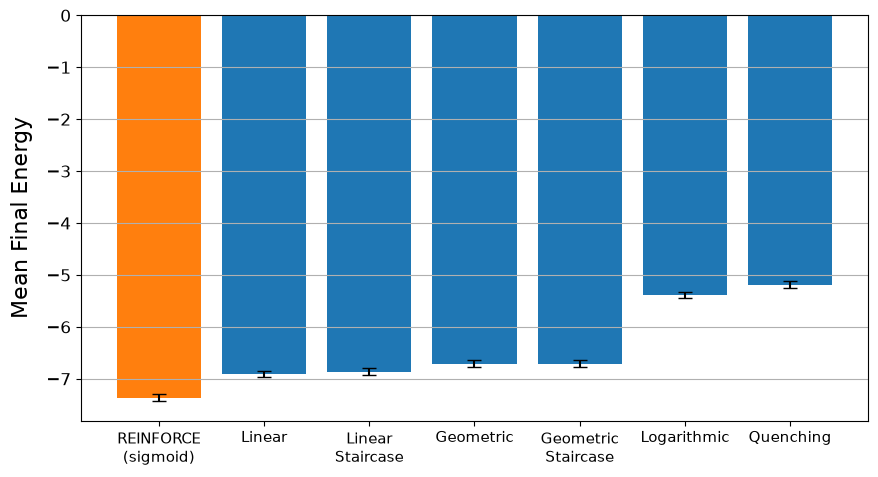

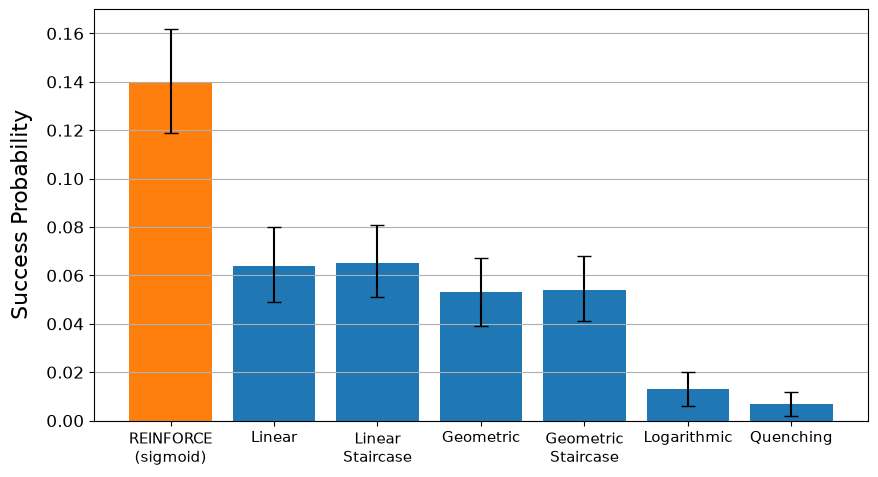

In [32]:
#plot all
# ---------- plot: mean final energy with bootstrap 95% CI ----------
names = sorted(results, key=lambda n: results[n]["mean"])
means = [results[n]["mean"] for n in names]
err_lo = [results[n]["mean"] - results[n]["mean_ci"][0] for n in names]
err_hi = [results[n]["mean_ci"][1] - results[n]["mean"] for n in names]
colors = ["tab:orange" if "REINFORCE" in n else "tab:blue" for n in names]

# wrap multi-word names onto two lines to stop x-axis labels from overlapping
wrapped_names = [n.replace(" ", "\n") for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(wrapped_names, means, yerr=[err_lo, err_hi], capsize=5, color=colors)
ax.set_ylabel("Mean Final Energy", fontsize=16, labelpad=10)
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig("mean_final_energy_bootstrap.png", dpi=150)
plt.show()

# ---------- plot: success probability with bootstrap 95% CI ----------
succ = [results[n]["success"] for n in names]
succ_lo = [results[n]["success"] - results[n]["success_ci"][0] for n in names]
succ_hi = [results[n]["success_ci"][1] - results[n]["success"] for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(wrapped_names, succ, yerr=[succ_lo, succ_hi], capsize=5, color=colors)
ax.set_ylabel("Success Probability", fontsize=16, labelpad=10)
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig("success_probability_bootstrap.png", dpi=150)
plt.show()

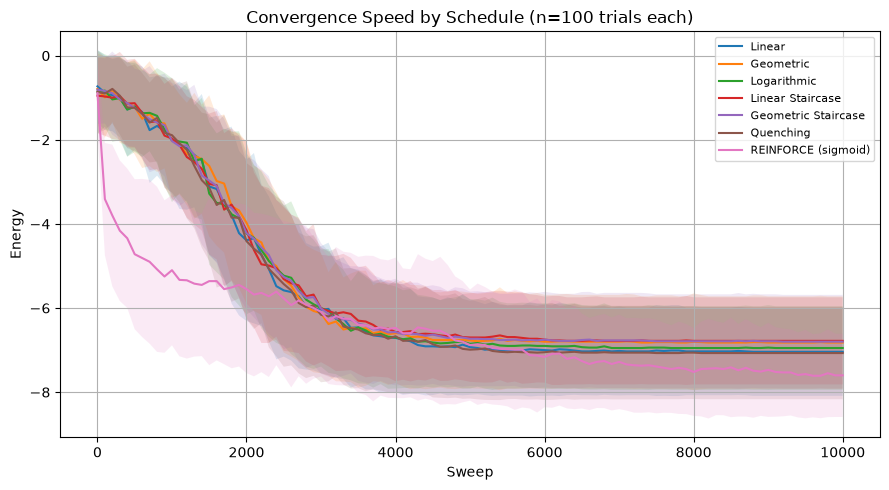

In [17]:
def run_sa_trial_with_trace(Gamma, A, N, beta, propose_move, laydowncoordinates,
                             valid_fold, energy, H, log_every=100):
    while True:
        d = np.random.randint(0, 4, size=N - 1)
        coordinates = laydowncoordinates(d)
        if valid_fold(coordinates):
            break

    E = energy(coordinates, Gamma, A, H)
    best_E = E
    trace = [E]

    for i in range(len(beta)):
        while True:
            d_new = propose_move(d)
            coords_new = laydowncoordinates(d_new)
            if valid_fold(coords_new):
                break
        E_new = energy(coords_new, Gamma, A, H)
        deltaE = E_new - E

        p_accept = 1.0 / (1.0 + np.exp(deltaE * beta[i]))
        if np.random.rand() < p_accept:
            d, coordinates, E = d_new, coords_new, E_new
            if E < best_E:
                best_E = E

        if (i + 1) % log_every == 0:
            trace.append(E)

    return best_E, E, np.array(trace)

# run a small batch per schedule (classical + tuned + your beta_of_t sigmoid, reconstructed
# from params saved in reinforce_sigmoid_schedule_cpu.pkl — no need to touch the other server)
def beta_of_t(t, beta_min, beta_max, k, t0):
    sigma_t = 1.0 / (1.0 + np.exp(-k * (t - t0)))
    return beta_min + (beta_max - beta_min) * sigma_t

t_arr = np.arange(num_sweeps)
reinforce_beta = beta_of_t(t_arr, *rf["best_params"])   # rf = your loaded pkl from before

n_conv_trials = 100
log_every = 100

traces = {}

for name, beta in {**{n: np.linspace(0.1, 10, num_sweeps) for n in classical_names},
                    "REINFORCE (sigmoid)": reinforce_beta}.items():
    runs = [run_sa_trial_with_trace(Gamma, A, N, beta, propose_move,
                                     laydowncoordinates, valid_fold, energy, H,
                                     log_every=log_every)[2]
            for _ in range(n_conv_trials)]
    traces[name] = np.array(runs)   # shape (n_conv_trials, n_checkpoints)

# plot mean energy vs sweep, with bootstrap-style band (just std here for speed)
sweep_axis = np.arange(0, num_sweeps + 1, log_every)
plt.figure(figsize=(9, 5))
for name, arr in traces.items():
    mean_trace = arr.mean(axis=0)
    std_trace = arr.std(axis=0)
    plt.plot(sweep_axis, mean_trace, label=name)
    plt.fill_between(sweep_axis, mean_trace - std_trace, mean_trace + std_trace, alpha=0.15)
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title(f"Convergence Speed by Schedule (n={n_conv_trials} trials each)")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig("convergence_speed.png", dpi=150)
plt.show()

In [18]:
import numpy as np

thresholds = [-5, -6, -7]   # pick whichever cutoffs are meaningful to report

print(f"{'Schedule':<22}" + "".join(f"{'E<'+str(t):>12}" for t in thresholds))
print("-" * (22 + 12 * len(thresholds)))

sweeps_to_threshold = {}   # keep for plotting/export later

for name, arr in traces.items():
    mean_trace = arr.mean(axis=0)
    row = []
    sweeps_to_threshold[name] = {}
    for t in thresholds:
        below = np.where(mean_trace <= t)[0]
        if len(below) == 0:
            row.append("never")
            sweeps_to_threshold[name][t] = None
        else:
            sweep_hit = sweep_axis[below[0]]
            row.append(sweep_hit)
            sweeps_to_threshold[name][t] = sweep_hit
    print(f"{name:<22}" + "".join(f"{str(v):>12}" for v in row))

Schedule                      E<-5        E<-6        E<-7
----------------------------------------------------------
Linear                        2300        2900        5400
Geometric                     2400        2900       never
Logarithmic                   2400        3000       never
Linear Staircase              2400        3000       never
Geometric Staircase           2400        3000       never
Quenching                     2300        3000        5300
REINFORCE (sigmoid)            800        2900        5800


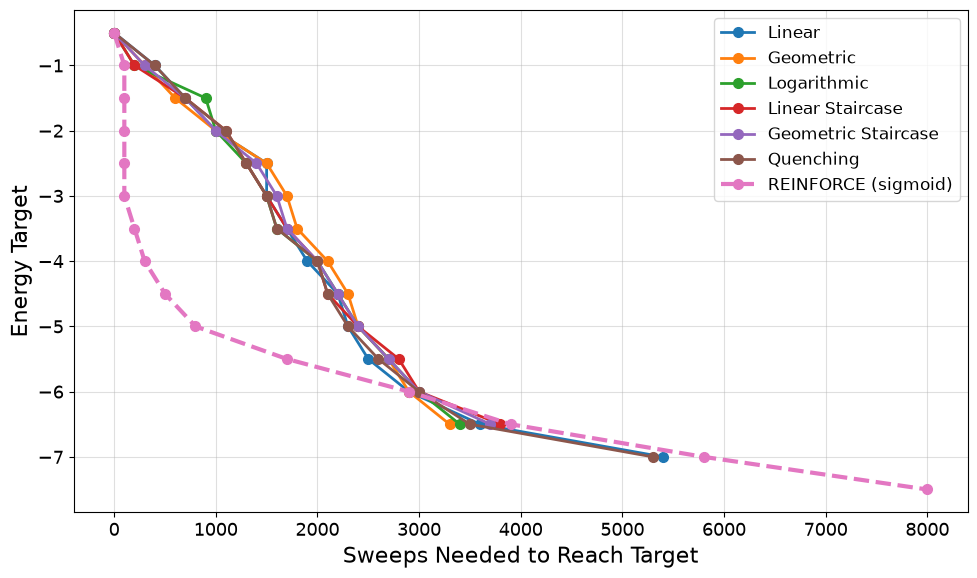

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# apply once, affects all plots below
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
})

# wider range: shallow (early separation) through deep (final plateau + beyond)
thresholds = np.arange(-0.5, -8.5, -0.5)   # -0.5, -1.0, ..., -8.0

sweeps_to_threshold = {}
for name, arr in traces.items():
    mean_trace = arr.mean(axis=0)
    sweeps_to_threshold[name] = []
    for t in thresholds:
        below = np.where(mean_trace <= t)[0]
        sweeps_to_threshold[name].append(sweep_axis[below[0]] if len(below) else np.nan)

# ---------- sweeps needed vs. energy target ----------
plt.figure(figsize=(10, 6))
for name, sweeps in sweeps_to_threshold.items():
    style = "--" if "REINFORCE" in name else "-"
    lw = 3 if "REINFORCE" in name else 2
    plt.plot(sweeps, thresholds, style, marker="o", markersize=7, lw=lw, label=name)
plt.xlabel("Sweeps Needed to Reach Target")
plt.ylabel("Energy Target")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("sweeps_vs_target_energy_wide.png", dpi=300)



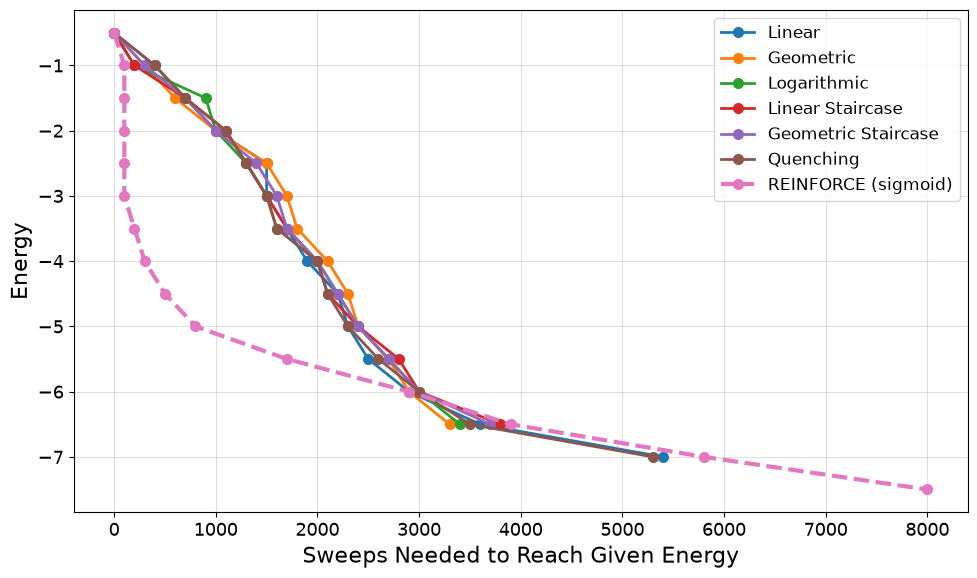

In [34]:
# ---------- sweeps needed vs. energy target ----------
plt.figure(figsize=(10, 6))
for name, sweeps in sweeps_to_threshold.items():
    style = "--" if "REINFORCE" in name else "-"
    lw = 3 if "REINFORCE" in name else 2
    plt.plot(sweeps, thresholds, style, marker="o", markersize=7, lw=lw, label=name)
plt.xlabel("Sweeps Needed to Reach Given Energy")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("sweeps_vs_target_energy_wide.png", dpi=300)
plt.show()

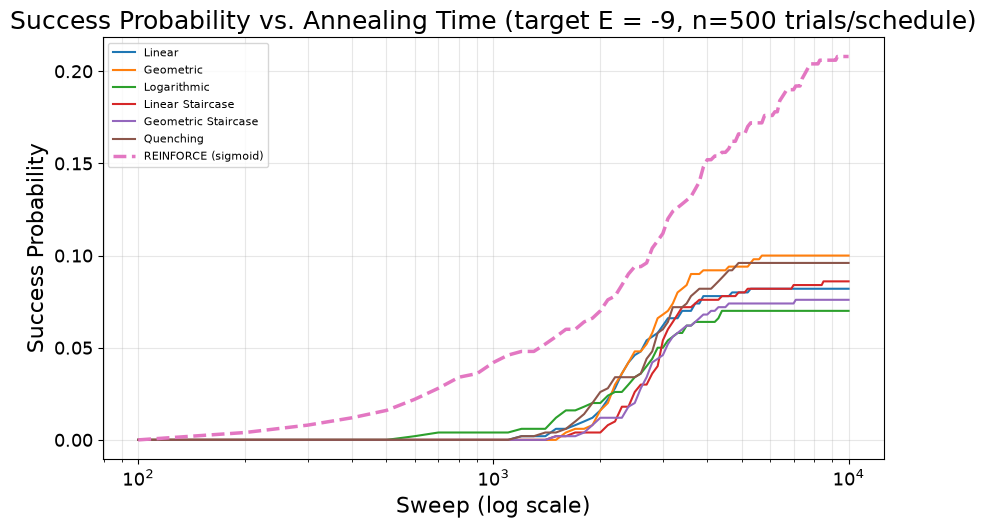

In [21]:
def run_sa_trial_success_trace(Gamma, A, N, beta, propose_move, laydowncoordinates,
                                valid_fold, energy, H, target_E, log_every=100):
    while True:
        d = np.random.randint(0, 4, size=N - 1)
        coordinates = laydowncoordinates(d)
        if valid_fold(coordinates):
            break

    E = energy(coordinates, Gamma, A, H)
    best_E = E
    hit_trace = [best_E <= target_E]

    for i in range(len(beta)):
        while True:
            d_new = propose_move(d)
            coords_new = laydowncoordinates(d_new)
            if valid_fold(coords_new):
                break
        E_new = energy(coords_new, Gamma, A, H)
        deltaE = E_new - E

        p_accept = 1.0 / (1.0 + np.exp(deltaE * beta[i]))
        if np.random.rand() < p_accept:
            d, coordinates, E = d_new, coords_new, E_new
            if E < best_E:
                best_E = E

        if (i + 1) % log_every == 0:
            hit_trace.append(best_E <= target_E)

    return np.array(hit_trace)

# run once per schedule -- same trial budget as your original benchmark, just with logging
n_trials = 500          # can drop to 200-300 if you want it even cheaper
log_every = 100
target_E = -9
num_sweeps = 10000

schedules_to_plot = {n: np.linspace(0.1, 10, num_sweeps) for n in classical_names}
schedules_to_plot["REINFORCE (sigmoid)"] = reinforce_beta   # from beta_of_t(*rf["best_params"])

sweep_axis = np.arange(0, num_sweeps + 1, log_every)
success_curves = {}

for name, beta in schedules_to_plot.items():
    hits = np.array([run_sa_trial_success_trace(Gamma, A, N, beta, propose_move,
                                                  laydowncoordinates, valid_fold, energy, H,
                                                  target_E, log_every=log_every)
                      for _ in range(n_trials)])
    success_curves[name] = hits.mean(axis=0)   # fraction of trials that hit target by each checkpoint

# ---------- plot: success probability vs sweep count, log-x, one line per schedule ----------
plt.figure(figsize=(9, 5.5))
for name, curve in success_curves.items():
    style = "--" if "REINFORCE" in name else "-"
    lw = 2.5 if "REINFORCE" in name else 1.5
    plt.plot(sweep_axis[1:], curve[1:], style, lw=lw, label=name)  # skip sweep=0 for log axis

plt.xscale("log")
plt.xlabel("Sweep (log scale)")
plt.ylabel("Success Probability")
plt.title(f"Success Probability vs. Annealing Time (target E = {target_E}, n={n_trials} trials/schedule)")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("success_probability_vs_sweeps.png", dpi=150)
plt.show()

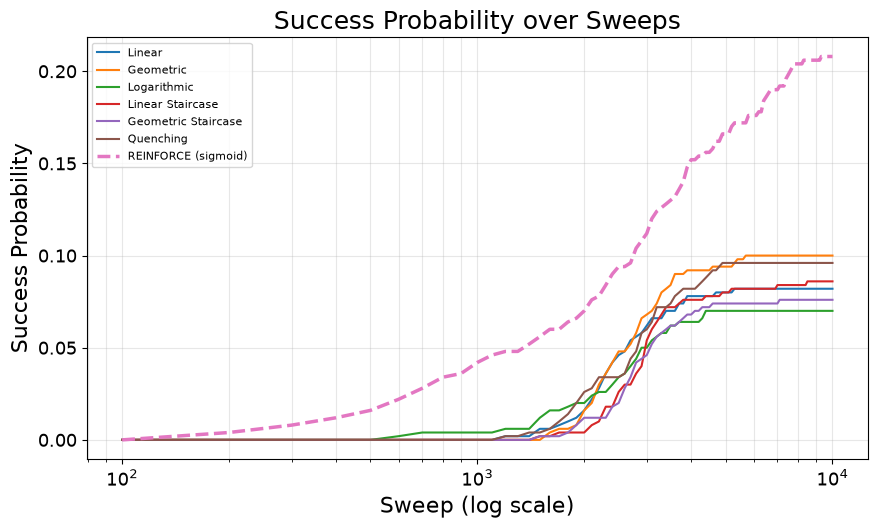

In [30]:
plt.figure(figsize=(9, 5.5))
for name, curve in success_curves.items():
    style = "--" if "REINFORCE" in name else "-"
    lw = 2.5 if "REINFORCE" in name else 1.5
    plt.plot(sweep_axis[1:], curve[1:], style, lw=lw, label=name) 


plt.xscale("log")
plt.xlabel("Sweep (log scale)")
plt.ylabel("Success Probability")
plt.title(f"Success Probability over Sweeps")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("success_probability_vs_sweeps.png", dpi=300)

In [28]:
plt.savefig("success_probability_vs_sweeps.png", dpi=300)

<Figure size 640x480 with 0 Axes>